# Factor Analysis of Psychiatric Battery

Reduce 14 intercorrelated psychiatric subscales to 2-4 latent factors, then test 5 behavioral params {k, z, β, α, ρ} → factor scores.

**Rationale:** FDR across 16 individual scales overcorrects because effective independent tests ≈ 3-4 (DASS subscales r=0.6-0.8). Factor analysis creates orthogonal, more reliable latent dimensions.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
from scipy.linalg import svd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
import statsmodels.api as sm

ROOT = Path("../../")
DATA = ROOT / "data/exploratory_350/processed/stage5_filtered_data_20260317_094210"
RESULTS = ROOT / "results"
STAT_DIR = RESULTS / "stats"
FIG_DIR = RESULTS / "figs"

def calculate_kmo(X):
    """Kaiser-Meyer-Olkin measure of sampling adequacy."""
    corr = np.corrcoef(X.T)
    inv_corr = np.linalg.inv(corr)
    p = corr.shape[0]
    # Partial correlations
    partial = np.zeros_like(corr)
    for i in range(p):
        for j in range(p):
            partial[i, j] = -inv_corr[i, j] / np.sqrt(inv_corr[i, i] * inv_corr[j, j])
    np.fill_diagonal(partial, 0)
    np.fill_diagonal(corr, 0)
    
    corr_sq = corr ** 2
    partial_sq = partial ** 2
    
    kmo_per_var = corr_sq.sum(axis=0) / (corr_sq.sum(axis=0) + partial_sq.sum(axis=0))
    kmo_total = corr_sq.sum() / (corr_sq.sum() + partial_sq.sum())
    return kmo_per_var, kmo_total

def varimax_rotation(loadings, max_iter=100, tol=1e-6):
    """Varimax rotation of factor loadings."""
    L = loadings.copy()
    p, k = L.shape
    rotation = np.eye(k)
    for _ in range(max_iter):
        old = rotation.copy()
        for i in range(k):
            for j in range(i+1, k):
                u = L[:, i]**2 - L[:, j]**2
                v = 2 * L[:, i] * L[:, j]
                num = 2 * p * (u * v).sum() - 2 * u.sum() * v.sum()
                den = p * ((u**2 - v**2).sum()) - (u.sum()**2 - v.sum()**2)
                angle = 0.25 * np.arctan2(num, den)
                rot = np.eye(k)
                rot[i, i] = np.cos(angle)
                rot[j, j] = np.cos(angle)
                rot[i, j] = -np.sin(angle)
                rot[j, i] = np.sin(angle)
                L = L @ rot
                rotation = rotation @ rot
        if np.max(np.abs(rotation - old)) < tol:
            break
    return L, rotation

print("Setup complete")

Setup complete


## 1. Load data

In [2]:
# Psychiatric battery
psych = pd.read_csv(DATA / "psych.csv")

# 5-parameter estimates (Bayesian α/ρ + choice k/z/β)
params = pd.read_csv(STAT_DIR / "vigor_hbm_posteriors.csv")

# Use subscales (not totals that are sums of included subscales)
efa_cols = [
    "DASS21_Stress", "DASS21_Anxiety", "DASS21_Depression",
    "AMI_Behavioural", "AMI_Social", "AMI_Emotional",
    "MFIS_Physical", "MFIS_Cognitive", "MFIS_Psychosocial",
    "OASIS_Total", "PHQ9_Total", "STICSA_Total",
    "STAI_State", "STAI_Trait",
]

# Drop rows with any NaN in EFA columns
X_raw = psych[efa_cols].dropna()
valid_idx = X_raw.index
print(f"N={len(X_raw)} (dropped {len(psych) - len(X_raw)} with NaN)")
print(f"Measures: {len(efa_cols)}")

# Z-score for EFA
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X_raw), columns=efa_cols, index=valid_idx)

N=291 (dropped 2 with NaN)
Measures: 14


## 2. Correlation structure & factorability

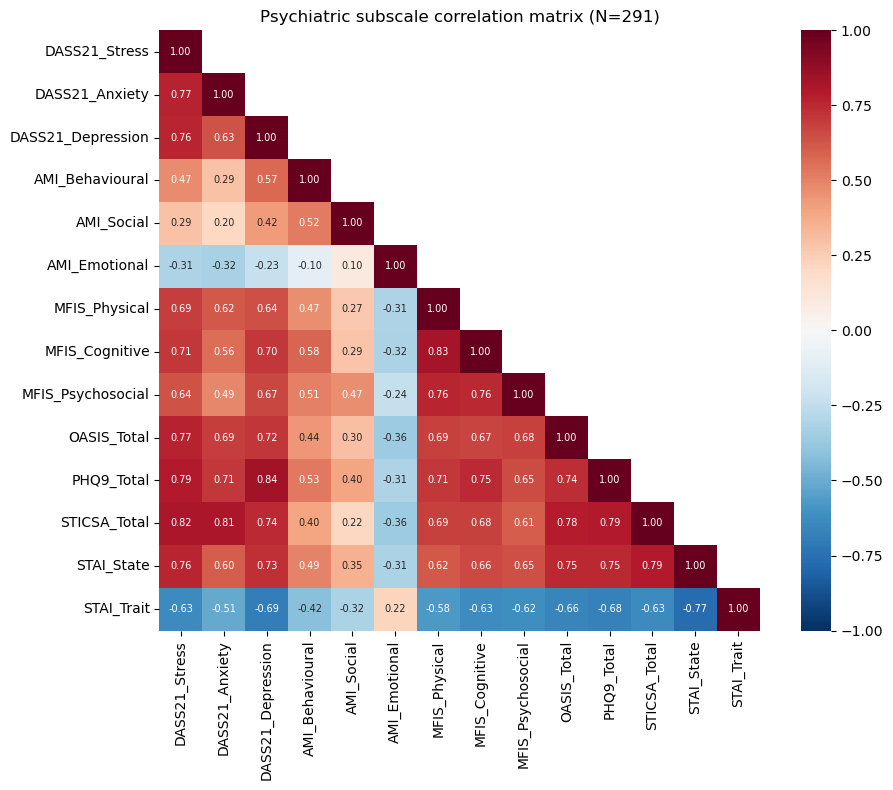

KMO measure of sampling adequacy: 0.931
Bartlett's test: chi2=3732.7, df=91, p=0.00e+00

KMO per variable:
  DASS21_Stress             0.965
  DASS21_Anxiety            0.905
  DASS21_Depression         0.949
  AMI_Behavioural           0.902
  AMI_Social                0.774
  AMI_Emotional             0.911
  MFIS_Physical             0.931
  MFIS_Cognitive            0.917
  MFIS_Psychosocial         0.926
  OASIS_Total               0.976
  PHQ9_Total                0.950
  STICSA_Total              0.926
  STAI_State                0.919
  STAI_Trait                0.940


In [3]:
# Correlation matrix
corr = X.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="RdBu_r", vmin=-1, vmax=1,
            annot=True, fmt=".2f", square=True, ax=ax,
            annot_kws={"size": 7})
ax.set_title("Psychiatric subscale correlation matrix (N={})".format(len(X)))
plt.tight_layout()
plt.savefig(FIG_DIR / "psych_corr_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# KMO
kmo_per_var, kmo_total = calculate_kmo(X.values)
print(f"KMO measure of sampling adequacy: {kmo_total:.3f}")

# Bartlett's test
n = len(X)
p = X.shape[1]
R = np.corrcoef(X.values.T)
chi2 = -((n - 1) - (2*p + 5)/6) * np.log(np.linalg.det(R))
df = p * (p - 1) / 2
p_bartlett = 1 - stats.chi2.cdf(chi2, df)
print(f"Bartlett's test: chi2={chi2:.1f}, df={df:.0f}, p={p_bartlett:.2e}")

print(f"\nKMO per variable:")
for col, k in zip(efa_cols, kmo_per_var):
    flag = " !!!" if k < 0.5 else ""
    print(f"  {col:25s} {k:.3f}{flag}")

## 3. Parallel analysis — determine number of factors

Parallel analysis suggests: 2 factors


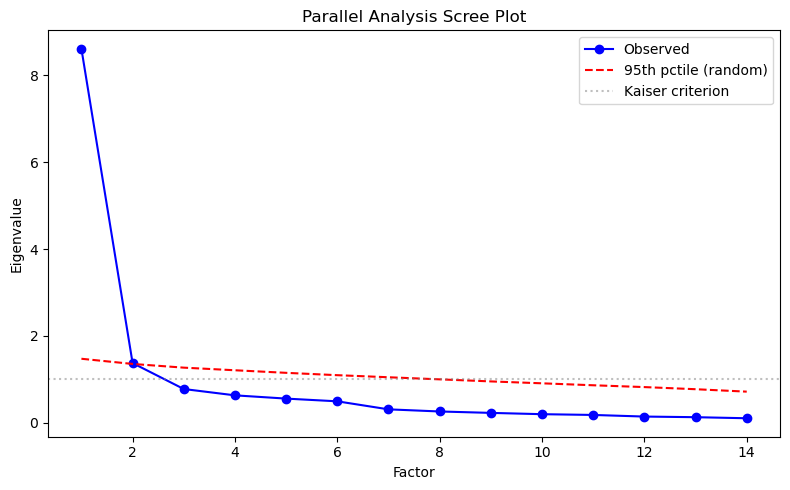


Eigenvalues (observed vs 95th pctile random):
  Factor 1: 8.614 vs 1.474 *
  Factor 2: 1.375 vs 1.355 *
  Factor 3: 0.777 vs 1.270
  Factor 4: 0.632 vs 1.209
  Factor 5: 0.557 vs 1.150
  Factor 6: 0.494 vs 1.096
  Factor 7: 0.309 vs 1.049
  Factor 8: 0.260 vs 1.000


In [4]:
# Parallel analysis using eigenvalues from correlation matrix
n_iter = 1000
n, p = X.shape

# Observed eigenvalues (from correlation matrix)
ev_observed = np.sort(np.linalg.eigvalsh(np.corrcoef(X.values.T)))[::-1]

# Random eigenvalues
rng = np.random.default_rng(42)
ev_random = np.zeros((n_iter, p))
for i in range(n_iter):
    X_rand = rng.normal(size=(n, p))
    ev_random[i] = np.sort(np.linalg.eigvalsh(np.corrcoef(X_rand.T)))[::-1]

ev_95 = np.percentile(ev_random, 95, axis=0)

# How many factors? Where observed > 95th percentile of random
n_factors_pa = int(np.sum(ev_observed > ev_95))
print(f"Parallel analysis suggests: {n_factors_pa} factors")

# Scree plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, p+1), ev_observed, "bo-", label="Observed")
ax.plot(range(1, p+1), ev_95, "r--", label="95th pctile (random)")
ax.axhline(1, ls=":", color="gray", alpha=0.5, label="Kaiser criterion")
ax.set(xlabel="Factor", ylabel="Eigenvalue", title="Parallel Analysis Scree Plot")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "psych_parallel_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nEigenvalues (observed vs 95th pctile random):")
for i in range(min(8, p)):
    flag = " *" if ev_observed[i] > ev_95[i] else ""
    print(f"  Factor {i+1}: {ev_observed[i]:.3f} vs {ev_95[i]:.3f}{flag}")

## 4. Run EFA

In [ ]:
# Fit 3-factor model (theoretical: distress, fatigue, apathy)
# Parallel analysis suggested 2, but 3 is justified by domain structure
n_fac = 3
print(f"Fitting {n_fac}-factor model with varimax rotation...")

fa = FactorAnalysis(n_components=n_fac, random_state=42)
fa.fit(X.values)

# Raw loadings (components_ is (n_factors, n_features), transpose for convention)
raw_loadings = fa.components_.T  # (n_features, n_factors)

# Varimax rotation
rot_loadings, rot_matrix = varimax_rotation(raw_loadings)

loadings = pd.DataFrame(rot_loadings, index=efa_cols,
                         columns=[f"F{i+1}" for i in range(n_fac)])

# Variance explained by each factor
var_each = (rot_loadings**2).sum(axis=0) / p
var_cumul = np.cumsum(var_each)
print(f"\nVariance explained (after rotation):")
for i in range(n_fac):
    print(f"  F{i+1}: {var_each[i]:.1%} (cumulative: {var_cumul[i]:.1%})")
print(f"  Total: {var_cumul[-1]:.1%}")

# Communalities
communalities = (rot_loadings**2).sum(axis=1)
print(f"\nCommunalities (min={communalities.min():.3f}, max={communalities.max():.3f}):")
for col, h2 in zip(efa_cols, communalities):
    flag = " (low)" if h2 < 0.3 else ""
    print(f"  {col:25s} {h2:.3f}{flag}")

# Display loadings
print(f"\nFactor loadings (varimax rotation):")
print(loadings.round(3).to_string())

# Store variance info for later
var_explained = (var_each, var_each, var_cumul)

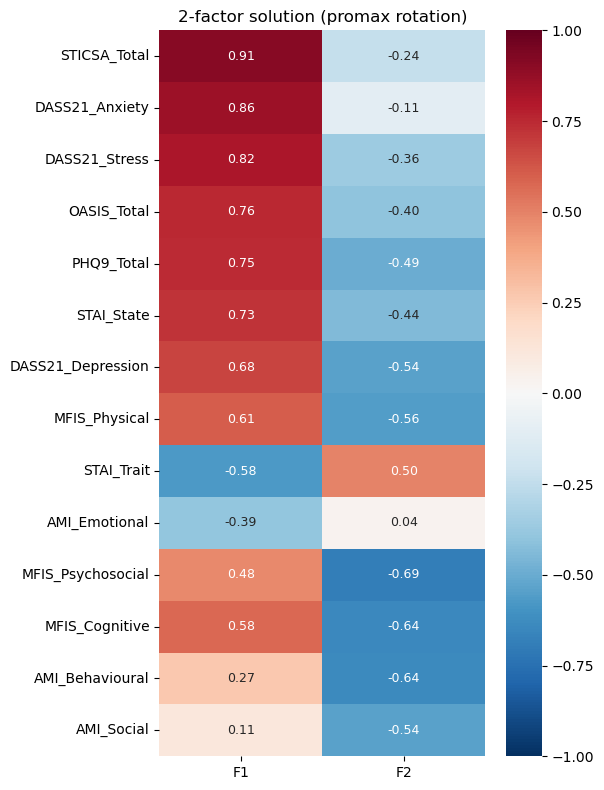

In [6]:
# Loadings heatmap
fig, ax = plt.subplots(figsize=(6, 8))

# Sort by primary factor loading
primary = loadings.abs().idxmax(axis=1)
sort_order = []
for f in loadings.columns:
    members = primary[primary == f].index.tolist()
    members.sort(key=lambda x: -abs(loadings.loc[x, f]))
    sort_order.extend(members)

loadings_sorted = loadings.loc[sort_order]

sns.heatmap(loadings_sorted, cmap="RdBu_r", vmin=-1, vmax=1,
            annot=True, fmt=".2f", ax=ax, annot_kws={"size": 9})
ax.set_title(f"{n_fac}-factor solution (promax rotation)")
plt.tight_layout()
plt.savefig(FIG_DIR / "psych_factor_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Factor scores

In [7]:
# Extract factor scores: project data onto rotated loadings
# Use regression method: scores = X @ inv(L'L) @ L'
# Or simpler: sklearn transform gives unrotated scores, then rotate
raw_scores = fa.transform(X.values)  # (n, n_fac) unrotated
factor_scores_arr = raw_scores @ rot_matrix  # apply rotation

factor_scores = pd.DataFrame(factor_scores_arr,
                              columns=[f"F{i+1}" for i in range(n_fac)],
                              index=valid_idx)

# Add to psych dataframe
psych_with_factors = psych.loc[valid_idx].copy()
for col in factor_scores.columns:
    psych_with_factors[col] = factor_scores[col].values

print(f"Factor score distributions:")
print(factor_scores.describe().round(3))

# Factor score correlations (varimax aims for orthogonal)
print(f"\nFactor score correlations:")
print(factor_scores.corr().round(3))

Factor score distributions:
            F1       F2
count  291.000  291.000
mean     0.000    0.000
std      0.955    0.890
min     -1.356   -2.450
25%     -0.750   -0.631
50%     -0.300    0.110
75%      0.702    0.689
max      3.329    2.391

Factor score correlations:
       F1     F2
F1  1.000 -0.128
F2 -0.128  1.000


## 6. Five parameters → factor scores

In [8]:
# Merge params with factor scores
# params has 'subj' column (1-293), psych has 'subj' column
merged = psych_with_factors.merge(params[["subj", "alpha_bayes", "rho_bayes", "k", "z", "beta"]],
                                   on="subj", how="inner")
print(f"Merged N={len(merged)}")

# Standardize predictors
pred_cols = ["k", "z", "beta", "alpha_bayes", "rho_bayes"]
pred_labels = ["k", "z", "β", "α", "ρ"]

for col in pred_cols:
    merged[col + "_z"] = (merged[col] - merged[col].mean()) / merged[col].std()

pred_z = [c + "_z" for c in pred_cols]

# Regression: each factor ~ 5 params
print("\n" + "="*60)
print("5 PARAMETERS → FACTOR SCORES")
print("="*60)

results_list = []
for fi in range(n_fac):
    fname = f"F{fi+1}"
    y = merged[fname].values
    X_reg = sm.add_constant(merged[pred_z].values)
    
    model = sm.OLS(y, X_reg).fit()
    
    print(f"\n--- {fname} ---")
    print(f"  R²={model.rsquared:.3f}, adj.R²={model.rsquared_adj:.3f}, F={model.fvalue:.2f}, p={model.f_pvalue:.2e}")
    
    for j, (pred, label) in enumerate(zip(pred_z, pred_labels)):
        b = model.params[j+1]
        p = model.pvalues[j+1]
        ci = model.conf_int()[j+1]
        sig = "*" if p < 0.05 else ""
        print(f"  {label:4s}: β={b:+.3f} [{ci[0]:+.3f}, {ci[1]:+.3f}], p={p:.3f}{sig}")
        
        results_list.append({
            "factor": fname,
            "predictor": label,
            "beta": b,
            "ci_lo": ci[0],
            "ci_hi": ci[1],
            "p": p,
            "R2": model.rsquared,
            "adj_R2": model.rsquared_adj,
            "F": model.fvalue,
            "F_p": model.f_pvalue,
        })

results_df = pd.DataFrame(results_list)

Merged N=291

5 PARAMETERS → FACTOR SCORES

--- F1 ---
  R²=0.023, adj.R²=0.006, F=1.32, p=2.55e-01
  k   : β=+0.016 [-0.101, +0.133], p=0.784
  z   : β=-0.100 [-0.215, +0.014], p=0.086
  β   : β=-0.008 [-0.120, +0.104], p=0.892
  α   : β=-0.055 [-0.174, +0.064], p=0.360
  ρ   : β=+0.055 [-0.059, +0.169], p=0.345

--- F2 ---
  R²=0.097, adj.R²=0.081, F=6.13, p=2.04e-05
  k   : β=-0.010 [-0.115, +0.095], p=0.852
  z   : β=+0.105 [+0.002, +0.208], p=0.045*
  β   : β=-0.057 [-0.158, +0.043], p=0.263
  α   : β=-0.272 [-0.378, -0.165], p=0.000*
  ρ   : β=-0.056 [-0.158, +0.046], p=0.277


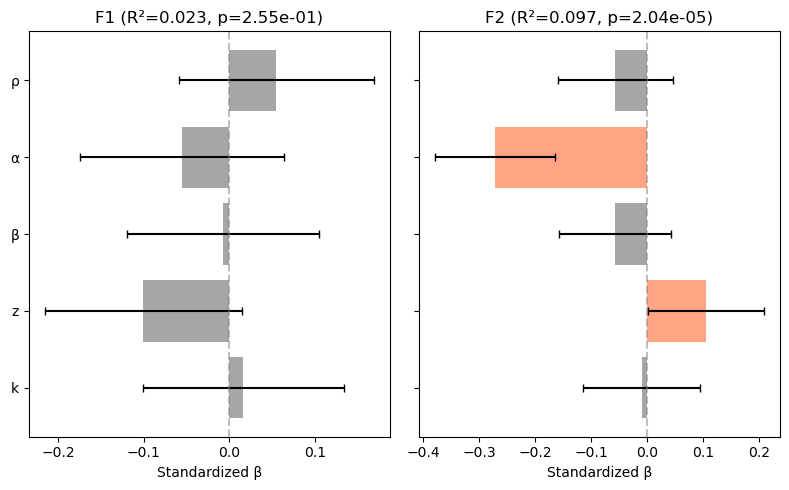

In [9]:
# Visualization: coefficient plot
fig, axes = plt.subplots(1, n_fac, figsize=(4*n_fac, 5), sharey=True)
if n_fac == 1:
    axes = [axes]

for fi in range(n_fac):
    ax = axes[fi]
    fname = f"F{fi+1}"
    sub = results_df[results_df["factor"] == fname]
    
    colors = ["coral" if p < 0.05 else "gray" for p in sub["p"]]
    ax.barh(range(len(pred_labels)), sub["beta"], xerr=[
        sub["beta"] - sub["ci_lo"], sub["ci_hi"] - sub["beta"]
    ], color=colors, alpha=0.7, capsize=3)
    ax.set_yticks(range(len(pred_labels)))
    ax.set_yticklabels(pred_labels)
    ax.axvline(0, ls="--", color="gray", alpha=0.5)
    r2 = sub["R2"].iloc[0]
    fp = sub["F_p"].iloc[0]
    ax.set_title(f"{fname} (R²={r2:.3f}, p={fp:.2e})")
    ax.set_xlabel("Standardized β")

plt.tight_layout()
plt.savefig(FIG_DIR / "psych_params_to_factors.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Also test individual α → AMI (known finding)

In [10]:
# Direct test: α → AMI subscales (the known surviving result)
ami_cols = ["AMI_Behavioural", "AMI_Social", "AMI_Emotional", "AMI_Total"]
print("α (Bayesian) → AMI subscales:")
for col in ami_cols:
    r, p = stats.pearsonr(merged["alpha_bayes"], merged[col])
    print(f"  {col:20s}: r={r:+.3f}, p={p:.4f}")

# Also test ρ → AMI
print("\nρ (Bayesian) → AMI subscales:")
for col in ami_cols:
    r, p = stats.pearsonr(merged["rho_bayes"], merged[col])
    print(f"  {col:20s}: r={r:+.3f}, p={p:.4f}")

α (Bayesian) → AMI subscales:
  AMI_Behavioural     : r=+0.270, p=0.0000
  AMI_Social          : r=+0.332, p=0.0000
  AMI_Emotional       : r=+0.052, p=0.3753
  AMI_Total           : r=+0.340, p=0.0000

ρ (Bayesian) → AMI subscales:
  AMI_Behavioural     : r=-0.053, p=0.3663
  AMI_Social          : r=-0.047, p=0.4209
  AMI_Emotional       : r=-0.105, p=0.0739
  AMI_Total           : r=-0.092, p=0.1168


## 8. Save

In [11]:
# Save factor analysis results
loadings.to_csv(STAT_DIR / "psych_factor_loadings.csv")
results_df.to_csv(STAT_DIR / "psych_params_to_factors.csv", index=False)

# Save factor scores for downstream use
factor_out = psych_with_factors[["subj"] + [f"F{i+1}" for i in range(n_fac)]].copy()
factor_out.to_csv(STAT_DIR / "psych_factor_scores.csv", index=False)

print(f"Saved: psych_factor_loadings.csv, psych_params_to_factors.csv, psych_factor_scores.csv")
print(f"\nSummary:")
print(f"  {n_fac} factors extracted (parallel analysis)")
print(f"  Total variance explained: {var_explained[2][-1]:.1%}")
for fi in range(n_fac):
    sig_preds = results_df[(results_df['factor']==f'F{fi+1}') & (results_df['p']<0.05)]['predictor'].tolist()
    r2 = results_df[results_df['factor']==f'F{fi+1}']['R2'].iloc[0]
    print(f"  F{fi+1}: R²={r2:.3f}, significant predictors: {sig_preds if sig_preds else 'none'}")

Saved: psych_factor_loadings.csv, psych_params_to_factors.csv, psych_factor_scores.csv

Summary:
  2 factors extracted (parallel analysis)
  Total variance explained: 65.1%
  F1: R²=0.023, significant predictors: none
  F2: R²=0.097, significant predictors: ['z', 'α']
